In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = str(PROJECT_ROOT / "src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

from soccer_ai.config import *
print("Project root:", PROJECT_ROOT)
print("Data dir    :", DATA_DIR)

Project root: C:\Users\pdenarie\OneDrive - Deloitte (O365D)\Desktop\Python own\Soccer_Broadcast_LVM
Data dir    : C:\Users\pdenarie\OneDrive - Deloitte (O365D)\Desktop\Python own\Soccer_Broadcast_LVM\data


# Tensor Decomposition Showcase — Custom RF-DETR with DINOv2 Backbone

This notebook provides a **complete, runnable walkthrough** of the tensor decomposition capabilities built into our custom RF-DETR pipeline.

## What we cover

| Section | Topic |
|---------|-------|
| § 1 | Tensor decomposition fundamentals + visual demo |
| § 2 | DINOv2 backbone internals and weight analysis |
| § 3 | Tensor Train (TT) decomposition of model weights |
| § 4 | CP (CANDECOMP/PARAFAC) decomposition of model weights |
| § 5 | Benchmarking utilities |
| § 6 | Automated search — best TT model for `RFDETRSegNano` on `dog.jpg` |
| § 7 | Automated search — best CP model for `RFDETRSegNano` on `dog.jpg` |
| § 8 | Memory footprint reduction plots + performance trade-off |
| § 9 | TT + Core Quantization — stacking fp16/bf16 on top of TT cores |
| § 10 | Video segmentation with the best quantized model |

---

### Background

Neural network weights are high-dimensional tensors.  
**Tensor decompositions** express these tensors as products of smaller factor matrices / core tensors, achieving **lossless-or-controlled-lossy compression** without changing the network's forward interface.

We target the **DINOv2 backbone** inside RF-DETR: its MLP blocks hold ~75% of backbone parameters, making them the highest-value compression targets.

The compression pipeline stacks two layers:
1. **TT decomposition** (§ 3 / § 6) — replaces dense weight matrices with small TT cores
2. **Core quantization** (§ 9) — casts those cores from float32 → float16/bfloat16, halving their storage

The best doubly-compressed model is then used to segment `football_play.mp4` in § 10.


---
## § 1 — Tensor Decomposition Fundamentals

To build intuition, we first compress a **raw image** using Tensor-Train decomposition.  
An RGB image of shape `(H, W, 3)` is reshaped into a higher-order tensor, then compressed by keeping only the most important singular vectors at each mode transition.

### Tensor Train (TT) decomposition

A tensor $\mathcal{X} \in \mathbb{R}^{I_1 \times I_2 \times \cdots \times I_N}$ is represented as a chain ("train") of 3-way cores:

$$
\mathcal{X}[i_1, \ldots, i_N] = G_1[i_1] \cdot G_2[i_2] \cdots G_N[i_N]
$$

where $G_k \in \mathbb{R}^{r_{k-1} \times I_k \times r_k}$ and $r_0 = r_N = 1$.  
The ranks $(r_1, \ldots, r_{N-1})$ control the trade-off between **accuracy** and **compression**.  
Setting $\varepsilon$ triggers automatic truncation via truncated SVD so that the relative error $\leq \varepsilon$.

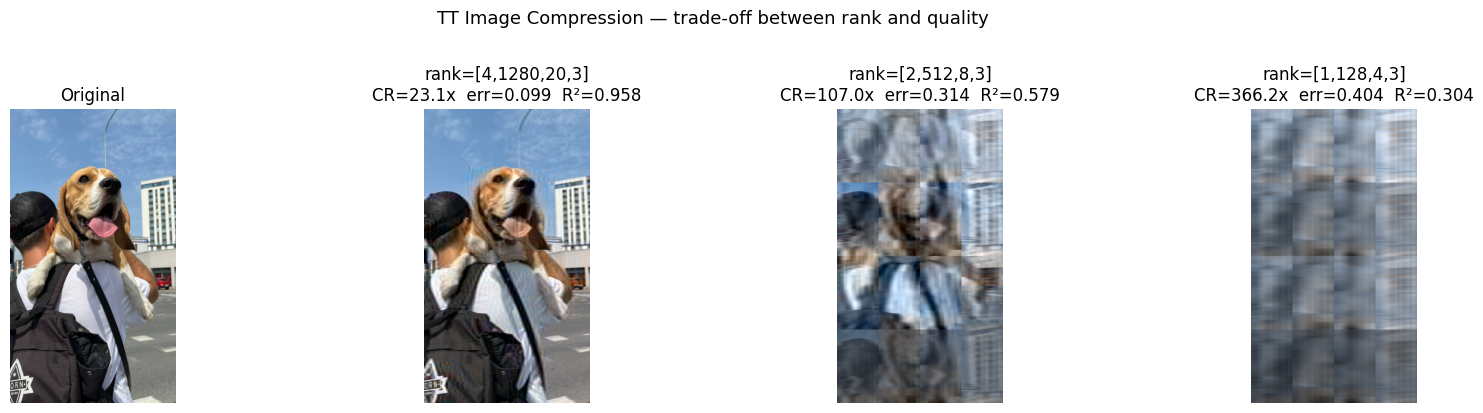

In [2]:
import numpy as np
import torch
import tntorch_pierre as tnp
from PIL import Image
from IPython.display import display
import matplotlib.pyplot as plt
from soccer_ai.utils import metrics

input_file = DATA_DIR / "raw" / "dog.jpg"
img = Image.open(input_file).convert("RGB")

# Reshape 1280×720×3 → 4×320×4×180×3 so TT has 5 modes to compress
arr = np.array(img).reshape(4, 320, 4, 180, 3, order="C")
tensor = torch.from_numpy(arr).float()

# Compress at a few different rank levels
rank_configs = [
    ([4, 1280, 20, 3], "rank=[4,1280,20,3]"),
    ([2, 512,  8,  3], "rank=[2,512,8,3]"),
    ([1, 128,  4,  3], "rank=[1,128,4,3]"),
]

fig, axes = plt.subplots(1, len(rank_configs) + 1, figsize=(18, 4))
axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

for ax, (ranks, label) in zip(axes[1:], rank_configs):
    tt = tnp.Tensor(tensor, ranks_tt=ranks)
    cr, rel_err, rmse, r2 = metrics(tensor, tt)
    rec = tt.numpy().reshape(1280, 720, 3, order="C").clip(0, 255).astype(np.uint8)
    ax.imshow(Image.fromarray(rec))
    ax.set_title(f"{label}\nCR={cr:.1f}x  err={rel_err:.3f}  R²={r2:.3f}")
    ax.axis("off")

plt.suptitle("TT Image Compression — trade-off between rank and quality", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## § 2 — DINOv2 Backbone Internals

RF-DETR uses a **DINOv2-small** Vision Transformer as its backbone.  
We use our custom `WindowedDinov2WithRegistersBackbone` variant which replaces global self-attention in non-output layers with local windowed attention for efficiency.

Each of the 12 transformer layers contains:
- **Multi-head Self-Attention** — `query`, `key`, `value`, `output.dense` linear layers
- **MLP block** — two linear layers `fc1: [384→1536]` and `fc2: [1536→384]`

The MLP layers are the primary compression target:
- $W_1 \in \mathbb{R}^{1536 \times 384}$ and $W_2 \in \mathbb{R}^{384 \times 1536}$ per layer
- 12 layers × 2 matrices × ~590K params ≈ **14.2M parameters** in the MLP blocks alone

In [3]:
import supervision as sv
from PIL import Image
from rfdetr_pierre import RFDETRSegNano
from rfdetr_pierre.util.coco_classes import COCO_CLASSES

# Load the segmentation nano model (baseline, no compression)
model_segment = RFDETRSegNano()

# Inspect backbone layer structure
backbone_layers = model_segment.model.model.backbone[0].encoder.encoder.encoder.layer
print(f"Number of DINOv2 backbone layers: {len(backbone_layers)}")
print()

blk0 = backbone_layers[0]
print("Layer 0 MLP:")
print(f"  fc1 weight shape: {blk0.mlp.fc1.weight.shape}   ({blk0.mlp.fc1.weight.numel():,} params)")
print(f"  fc2 weight shape: {blk0.mlp.fc2.weight.shape}   ({blk0.mlp.fc2.weight.numel():,} params)")
print()
print("Layer 0 Attention:")
print(f"  query shape: {blk0.attention.attention.query.weight.shape}")
print(f"  key   shape: {blk0.attention.attention.key.weight.shape}")
print(f"  value shape: {blk0.attention.attention.value.weight.shape}")

# Quick detection on dog.jpg
image = Image.open(DATA_DIR / "raw" / "dog.jpg")
detections = model_segment.predict(image, threshold=0.35)
labels = [COCO_CLASSES[c] for c in detections.class_id]
print(f"\nBaseline detections on dog.jpg: {labels}")

[2026-03-17 16:52:46] [INFO] rf-detr - Downloading pretrained weights for rf-detr-seg-nano.pt


rf-detr-seg-nano.pt: 100%|██████████| 128M/128M [00:08<00:00, 15.1MiB/s] 


[2026-03-17 16:52:59] [INFO] rf-detr - MD5 validation successful for rf-detr-seg-nano.pt


[2026-03-17 16:52:59] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-17 16:52:59] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-17 16:53:00] [INFO] rf-detr - Loading pretrain weights


[2026-03-17 16:53:01] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


Number of DINOv2 backbone layers: 12

Layer 0 MLP:
  fc1 weight shape: torch.Size([1536, 384])   (589,824 params)
  fc2 weight shape: torch.Size([384, 1536])   (589,824 params)

Layer 0 Attention:
  query shape: torch.Size([384, 384])
  key   shape: torch.Size([384, 384])
  value shape: torch.Size([384, 384])

Baseline detections on dog.jpg: ['dog', 'backpack', 'car', 'person', 'person']


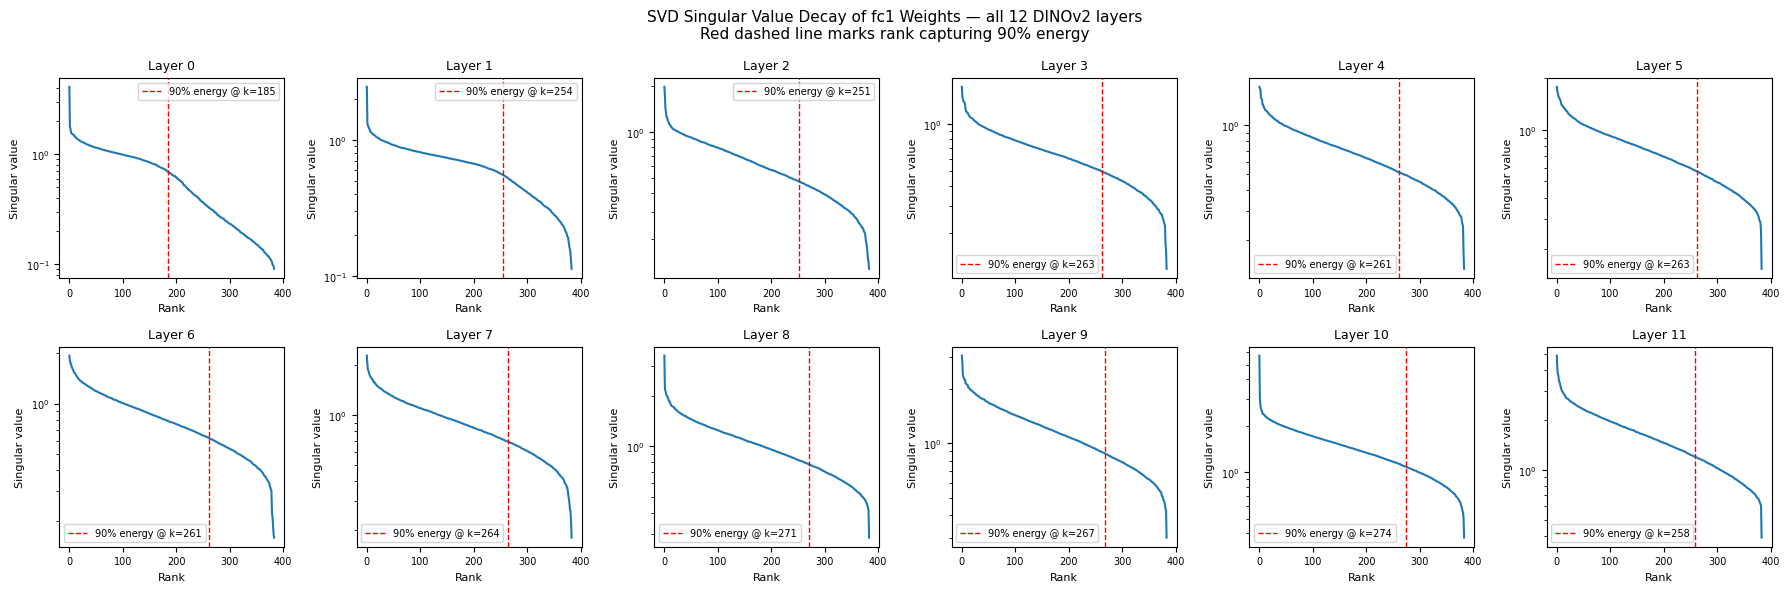

Key insight: singular values decay rapidly → weights are effectively low-rank → significant compression possible.


In [4]:
# SVD analysis of MLP weights across all layers
# Rapidly decaying singular values → low-rank structure → ideal for decomposition

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
axes = axes.flatten()

for idx, layer in enumerate(backbone_layers):
    W1 = layer.mlp.fc1.weight.detach().cpu()  # [1536, 384]
    _, S, _ = torch.linalg.svd(W1, full_matrices=False)
    s_np = S.numpy()
    # Fraction of energy in first k singular values
    energy = np.cumsum(s_np**2) / np.sum(s_np**2)
    k90 = int(np.searchsorted(energy, 0.90)) + 1

    ax = axes[idx]
    ax.semilogy(s_np, linewidth=1.5)
    ax.axvline(k90, color="red", linestyle="--", linewidth=1, label=f"90% energy @ k={k90}")
    ax.set_title(f"Layer {idx}", fontsize=9)
    ax.set_xlabel("Rank", fontsize=8)
    ax.set_ylabel("Singular value", fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle("SVD Singular Value Decay of fc1 Weights — all 12 DINOv2 layers\n"
             "Red dashed line marks rank capturing 90% energy", fontsize=11)
plt.tight_layout()
plt.show()

print("Key insight: singular values decay rapidly → weights are effectively low-rank → significant compression possible.")

---
## § 3 — Tensor Train (TT) Decomposition of Model Weights

### Joint MLP Compression Strategy

Instead of compressing $W_1$ and $W_2$ independently, we stack them into a single 3D tensor:

$$
F = \text{stack}(W_1, W_2^\top) \in \mathbb{R}^{2 \times 1536 \times 384}
$$

This joint representation:
1. Captures the **shared statistical structure** between the two matrices
2. Halves the number of TT decompositions needed per layer
3. Allows TT cores to encode cross-matrix correlations

After TT compression: $\hat{F} = \text{TT}(F)$   →   $\hat{W}_1 = \hat{F}[0,:,:]$ and $\hat{W}_2 = \hat{F}[1,:,:]^\top$

The `tt_factorize()` method applies this to the live model, replacing `Dinov2WithRegistersMLP` modules with `TTDinov2WithRegistersMLP` (lazy-reconstruct forward pass).

**Control parameters:**
- `eps_backbone_mlp` — TT truncation tolerance (higher → more compression, less accuracy)
- `layer_ids` — which backbone layers to compress (e.g., `[8,9,10,11]` = last 4)
- `factorize_backbone_attention` — also compress Q/K/V/Out linear layers
- `factorize_decoder_ffn` — also compress transformer decoder FFN

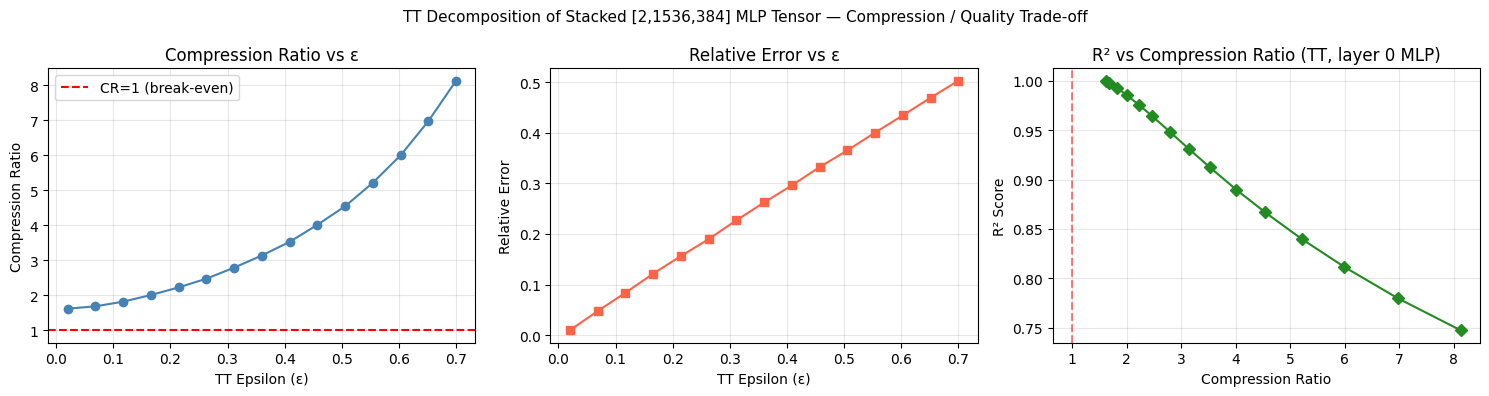

In [5]:
# TT compression vs error trade-off for a single MLP layer (layer 0)
# We sweep epsilon and measure compression ratio, relative error, RMSE, R²

blk0 = backbone_layers[0]
W1 = blk0.mlp.fc1.weight.detach().cpu()  # [1536, 384]
W2 = blk0.mlp.fc2.weight.detach().cpu()  # [384, 1536]

# Build stacked tensor [2, 1536, 384]
F = torch.stack([W1, W2.T], dim=0)

eps_values = np.linspace(0.02, 0.70, 15)
results = []

for eps in eps_values:
    tt = tnp.Tensor(F, eps=eps)
    cr, rel_err, rmse, r2 = metrics(F, tt)
    tt_numel = sum(c.numel() for c in tt.cores)
    results.append({"eps": eps, "cr": cr, "rel_err": rel_err, "rmse": rmse, "r2": r2, "tt_numel": tt_numel})

eps_arr  = [r["eps"] for r in results]
cr_arr   = [r["cr"]  for r in results]
err_arr  = [r["rel_err"] for r in results]
r2_arr   = [r["r2"]  for r in results]
rmse_arr = [r["rmse"] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(eps_arr, cr_arr, "o-", color="steelblue")
axes[0].axhline(1.0, color="red", linestyle="--", label="CR=1 (break-even)")
axes[0].set_xlabel("TT Epsilon (ε)")
axes[0].set_ylabel("Compression Ratio")
axes[0].set_title("Compression Ratio vs ε")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(eps_arr, err_arr, "s-", color="tomato")
axes[1].set_xlabel("TT Epsilon (ε)")
axes[1].set_ylabel("Relative Error")
axes[1].set_title("Relative Error vs ε")
axes[1].grid(True, alpha=0.3)

axes[2].plot(cr_arr, r2_arr, "D-", color="forestgreen")
axes[2].axvline(1.0, color="red", linestyle="--", alpha=0.5)
axes[2].set_xlabel("Compression Ratio")
axes[2].set_ylabel("R² Score")
axes[2].set_title("R² vs Compression Ratio (TT, layer 0 MLP)")
axes[2].grid(True, alpha=0.3)

plt.suptitle("TT Decomposition of Stacked [2,1536,384] MLP Tensor — Compression / Quality Trade-off", fontsize=11)
plt.tight_layout()
plt.show()

---
## § 4 — CP (CANDECOMP/PARAFAC) Decomposition

CP decomposition expresses an $N$-way tensor as a sum of $R$ rank-1 tensors:

$$
\mathcal{X} \approx \sum_{r=1}^{R} a_r^{(1)} \otimes a_r^{(2)} \otimes \cdots \otimes a_r^{(N)}
$$

For a matrix $W \in \mathbb{R}^{m \times n}$, CP rank-$R$ gives:

$$W \approx \sum_{r=1}^R u_r v_r^\top$$

— equivalent to a rank-$R$ truncated SVD. Storage: $(m + n) \cdot R$ vs $m \cdot n$.

### Implementation

We support three solvers:
| Solver | Description |
|--------|-------------|
| `tensorly_als` | Alternating Least Squares (TensorLy), with multi-start HOSVD/SVD/random init |
| `scipy_nls` | SciPy TRF nonlinear least squares with robust losses (`soft_l1`, `huber`, `cauchy`) |
| `torch_lbfgs` | PyTorch LBFGS on CP factors with warm ALS start |

The `cp_factorize()` method replaces `Dinov2WithRegistersMLP` with `CPDinov2WithRegistersMLP`.

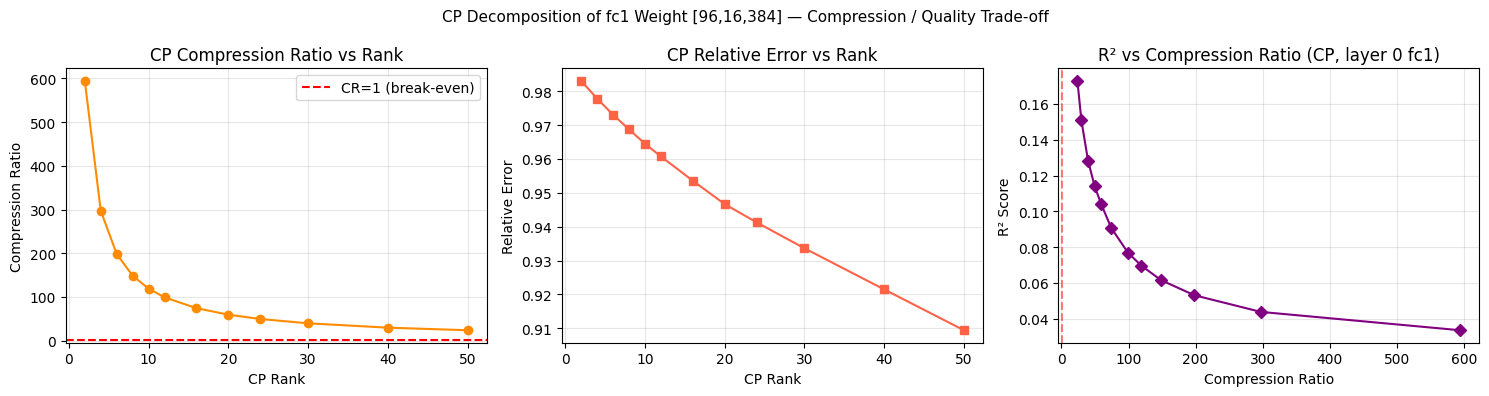

In [6]:
# CP compression vs error for a single MLP layer
import tntorch_pierre as tnp
import torch
import numpy as np
import matplotlib.pyplot as plt
from soccer_ai.utils import metrics

blk0 = backbone_layers[0]
W1 = blk0.mlp.fc1.weight.detach().cpu()  # [1536, 384]

# Reshape to 3D for proper CP decomposition: split 1536 → 96×16, keep 384
W1_3d = W1.reshape(96, 16, 384)  # 96*16 = 1536, third mode = 384

cp_ranks = [2, 4, 6, 8, 10, 12, 16, 20, 24, 30, 40, 50]
cp_results = []

for rank in cp_ranks:
    try:
        cp = tnp.Tensor(W1_3d, ranks_cp=rank, max_iter=50, tol=1e-6)
        cr, rel_err, rmse, r2 = metrics(W1_3d, cp)
        cp_numel = sum(f.numel() for f in cp.cores)
        cp_results.append({"rank": rank, "cr": cr, "rel_err": rel_err, "rmse": rmse, "r2": r2})
    except Exception as e:
        print(f"  rank={rank} failed: {e}")

ranks_arr = [r["rank"] for r in cp_results]
cr_cp     = [r["cr"]   for r in cp_results]
err_cp    = [r["rel_err"] for r in cp_results]
r2_cp     = [r["r2"]   for r in cp_results]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ranks_arr, cr_cp, "o-", color="darkorange")
axes[0].axhline(1.0, color="red", linestyle="--", label="CR=1 (break-even)")
axes[0].set_xlabel("CP Rank")
axes[0].set_ylabel("Compression Ratio")
axes[0].set_title("CP Compression Ratio vs Rank")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ranks_arr, err_cp, "s-", color="tomato")
axes[1].set_xlabel("CP Rank")
axes[1].set_ylabel("Relative Error")
axes[1].set_title("CP Relative Error vs Rank")
axes[1].grid(True, alpha=0.3)

axes[2].plot(cr_cp, r2_cp, "D-", color="purple")
axes[2].axvline(1.0, color="red", linestyle="--", alpha=0.5)
axes[2].set_xlabel("Compression Ratio")
axes[2].set_ylabel("R² Score")
axes[2].set_title("R² vs Compression Ratio (CP, layer 0 fc1)")
axes[2].grid(True, alpha=0.3)

plt.suptitle("CP Decomposition of fc1 Weight [96,16,384] — Compression / Quality Trade-off", fontsize=11)
plt.tight_layout()
plt.show()


---
## § 5 — Benchmarking Utilities

Helper functions for measuring model memory usage and inference latency:  
- `full_model_size_bytes()` — counts all registered parameters, TT cores, and CP factor matrices  
- `benchmark_predict_strict()` — warmup + GPU-synchronized timing with summary statistics  
- `human_bytes()` — clean human-readable byte formatting

In [7]:
import time
import numpy as np
import torch


def human_bytes(n):
    for unit in ("B", "KB", "MB", "GB", "TB"):
        if n < 1024.0:
            return f"{n:.2f} {unit}"
        n /= 1024.0
    return f"{n:.2f} PB"


def bytes_tensor(t):
    return t.numel() * t.element_size()


def _bytes_of_obj_unique(obj, seen_ids):
    if isinstance(obj, (torch.Tensor, np.ndarray)):
        oid = id(obj)
        if oid in seen_ids:
            return 0
        seen_ids.add(oid)
        if isinstance(obj, torch.Tensor):
            return obj.numel() * obj.element_size()
        return obj.nbytes
    if isinstance(obj, (list, tuple, set)):
        return sum(_bytes_of_obj_unique(x, seen_ids) for x in obj)
    if isinstance(obj, dict):
        return sum(_bytes_of_obj_unique(v, seen_ids) for v in obj.values())
    return 0


def full_model_size_bytes(
    model_input,
    include_tt_cores=True,
    include_cp_state=True,
    reference_bytes=None,
    verbose=False,
):
    """Count total model memory including TT cores and CP factor matrices."""
    net = model_input.model.model
    total = 0
    registered_tensor_ids = set()

    for p in net.parameters():
        total += bytes_tensor(p)
        registered_tensor_ids.add(id(p))
    for b in net.buffers():
        total += bytes_tensor(b)
        registered_tensor_ids.add(id(b))

    seen_ids = set(registered_tensor_ids)
    tt_extra = 0
    if include_tt_cores:
        for m in net.modules():
            if hasattr(m, "tt_tensor") and hasattr(m.tt_tensor, "cores"):
                tt_extra += _bytes_of_obj_unique(m.tt_tensor.cores, seen_ids)

    cp_extra = 0
    if include_cp_state:
        cp_attr_tokens = ("cp", "factor", "decomp", "parafac", "lambda")
        for m in net.modules():
            for attr_name, attr_value in vars(m).items():
                if attr_name in ("_parameters", "_buffers", "_modules"):
                    continue
                if not any(tok in attr_name.lower() for tok in cp_attr_tokens):
                    continue
                cp_extra += _bytes_of_obj_unique(attr_value, seen_ids)

    total_final = total + tt_extra + cp_extra
    compression_rate = None
    if reference_bytes is not None and total_final > 0:
        compression_rate = reference_bytes / total_final

    if verbose:
        print(f"  Registered params+buffers : {human_bytes(total)}")
        print(f"  Extra TT cores            : {human_bytes(tt_extra)}")
        print(f"  Extra CP/factor state     : {human_bytes(cp_extra)}")
        print(f"  Total                     : {human_bytes(total_final)}")
        if compression_rate is not None:
            print(f"  Compression rate          : {compression_rate:.3f}x")

    return {
        "total_bytes": total_final,
        "registered_bytes": total,
        "tt_extra_bytes": tt_extra,
        "cp_extra_bytes": cp_extra,
        "compression_rate": compression_rate,
    }


def _sync_if_needed():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def benchmark_predict_strict(model, image, threshold=0.35, warmup_runs=3, timed_runs=8, label="model"):
    """Warmup + GPU-synchronized timing with robust summary stats."""
    for _ in range(warmup_runs):
        model.predict(image, threshold=threshold)
        _sync_if_needed()

    times = []
    for _ in range(timed_runs):
        _sync_if_needed()
        t0 = time.perf_counter()
        model.predict(image, threshold=threshold)
        _sync_if_needed()
        times.append(time.perf_counter() - t0)

    arr = np.array(times)
    return {
        "label": label,
        "mean_s": float(arr.mean()),
        "median_s": float(np.median(arr)),
        "std_s": float(arr.std(ddof=1)),
        "p90_s": float(np.percentile(arr, 90)),
    }


print("Utilities loaded.")

Utilities loaded.


---
## § 6 — Automated Best-TT-Model Search

We sweep over a grid of TT configurations and score each using:

$$
\text{score} = \frac{\text{compression\_rate}}{\text{latency\_ratio}} \times \min\!\left(1, \frac{N_{\text{dets}}}{N_{\text{baseline}}}\right)
$$

Higher score = more compression AND faster AND same detection quality.

**Grid dimensions:**
- `ε` ∈ {0.1, 0.2, 0.3, 0.5}
- components: MLP only | MLP+Attention | MLP+DecoderFFN | MLP+ATT+FFN (full)
- target layers: last 4 `[8,9,10,11]`

In [8]:
# Establish baseline measurements
from rfdetr_pierre import RFDETRSegNano
from PIL import Image
import torch

image = Image.open(DATA_DIR / "raw" / "dog.jpg")

baseline_model = RFDETRSegNano()
baseline_size_info = full_model_size_bytes(baseline_model, verbose=True)
baseline_bytes = baseline_size_info["total_bytes"]

print()
baseline_bench = benchmark_predict_strict(
    baseline_model, image, threshold=0.35, warmup_runs=3, timed_runs=8, label="baseline"
)
baseline_dets = baseline_model.predict(image, threshold=0.35)
baseline_det_count = len(baseline_dets)

print(f"Baseline model size  : {human_bytes(baseline_bytes)}")
print(f"Baseline latency     : {baseline_bench['mean_s']:.4f}s (mean) | {baseline_bench['p90_s']:.4f}s (p90)")
print(f"Baseline detections  : {baseline_det_count} objects on dog.jpg")

[2026-03-17 16:53:42] [INFO] rf-detr - File rf-detr-seg-nano.pt already exists with correct MD5 hash.


[2026-03-17 16:53:42] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-17 16:53:42] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-17 16:53:44] [INFO] rf-detr - Loading pretrain weights


[2026-03-17 16:53:46] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


  Registered params+buffers : 128.09 MB
  Extra TT cores            : 0.00 B
  Extra CP/factor state     : 0.00 B
  Total                     : 128.09 MB

Baseline model size  : 128.09 MB
Baseline latency     : 1.5541s (mean) | 1.8873s (p90)
Baseline detections  : 5 objects on dog.jpg


In [9]:
# Automated TT configuration sweep
import copy

TT_CONFIGS = [
    # (name,  layer_ids,       mlp,   attn,  ffn,   eps_mlp, eps_attn, eps_ffn)
    ("TT-MLP-ε0.1",       [8,9,10,11], True,  False, False, 0.10, None, None),
    ("TT-MLP-ε0.2",       [8,9,10,11], True,  False, False, 0.20, None, None),
    ("TT-MLP-ε0.3",       [8,9,10,11], True,  False, False, 0.30, None, None),
    ("TT-MLP-ε0.5",       [8,9,10,11], True,  False, False, 0.50, None, None),
    ("TT-MLP+ATT-ε0.2",   [8,9,10,11], True,  True,  False, 0.20, 0.20, None),
    ("TT-MLP+ATT-ε0.3",   [8,9,10,11], True,  True,  False, 0.30, 0.30, None),
    ("TT-MLP+FFN-ε0.3",   [8,9,10,11], True,  False, True,  0.30, None, 0.05),
    ("TT-FULL-ε0.2-all",  "all",        True,  True,  True,  0.20, 0.20, 0.05),
]

tt_results = []
best_tt_score = -float("inf")
best_tt_model = None
best_tt_name  = None

print(f"{'Config':<25} {'Size':>9} {'CR':>6} {'Latency':>9} {'Lat.Ratio':>10} {'Dets':>5} {'Score':>8}")
print("-" * 80)

for name, layer_ids, do_mlp, do_attn, do_ffn, eps_mlp, eps_attn, eps_ffn in TT_CONFIGS:
    try:
        model = RFDETRSegNano()
        kwargs = dict(
            layer_ids=layer_ids,
            cache_policy="none",
            verbose=False,
            factorize_backbone_mlp=do_mlp,
            factorize_backbone_attention=do_attn,
            factorize_decoder_ffn=do_ffn,
        )
        if eps_mlp  is not None: kwargs["eps_backbone_mlp"]       = eps_mlp
        if eps_attn is not None: kwargs["eps_backbone_attention"]  = eps_attn
        if eps_ffn  is not None: kwargs["eps_decoder_ffn"]         = eps_ffn

        model = model.tt_factorize(**kwargs)
        size_info = full_model_size_bytes(model, reference_bytes=baseline_bytes)
        bench     = benchmark_predict_strict(model, image, warmup_runs=2, timed_runs=6, label=name)
        dets      = model.predict(image, threshold=0.35)
        n_dets    = len(dets)

        cr  = size_info["compression_rate"] or 1.0
        lat_ratio = bench["mean_s"] / baseline_bench["mean_s"]
        det_ratio = n_dets / max(1, baseline_det_count)
        score = cr / lat_ratio * min(1.0, det_ratio)

        result = {
            "name": name, "compression_rate": cr, "size_bytes": size_info["total_bytes"],
            "latency_mean_s": bench["mean_s"], "latency_ratio": lat_ratio,
            "det_count": n_dets, "det_ratio": det_ratio, "score": score, "model": model,
        }
        tt_results.append(result)

        print(f"{name:<25} {human_bytes(size_info['total_bytes']):>9} {cr:>6.2f}x "
              f"{bench['mean_s']:>7.4f}s {lat_ratio:>10.2f}x {n_dets:>5} {score:>8.4f}")

        if score > best_tt_score:
            best_tt_score = score
            best_tt_model = model
            best_tt_name  = name

    except Exception as exc:
        print(f"{name:<25} FAILED: {exc}")

print()
print(f"Best TT config : {best_tt_name}  (score={best_tt_score:.4f})")

Config                         Size     CR   Latency  Lat.Ratio  Dets    Score
--------------------------------------------------------------------------------
[2026-03-17 16:54:12] [INFO] rf-detr - File rf-detr-seg-nano.pt already exists with correct MD5 hash.


[2026-03-17 16:54:12] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-17 16:54:12] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-17 16:54:12] [INFO] rf-detr - Loading pretrain weights


[2026-03-17 16:54:17] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


TT-MLP-ε0.1               120.84 MB   1.06x  1.6799s       1.08x     5   0.9805
[2026-03-17 16:54:33] [INFO] rf-detr - File rf-detr-seg-nano.pt already exists with correct MD5 hash.


...

TT-MLP+FFN-ε0.3           107.82 MB   1.19x  2.0916s       1.35x     4   0.7061
[2026-03-17 16:57:32] [INFO] rf-detr - File rf-detr-seg-nano.pt already exists with correct MD5 hash.


[2026-03-17 16:57:32] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-17 16:57:32] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-17 16:57:33] [INFO] rf-detr - Loading pretrain weights


[2026-03-17 16:57:51] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


TT-FULL-ε0.2-all           82.62 MB   1.55x  1.7451s       1.12x     5   1.3807

Best TT config : TT-FULL-ε0.2-all  (score=1.3807)


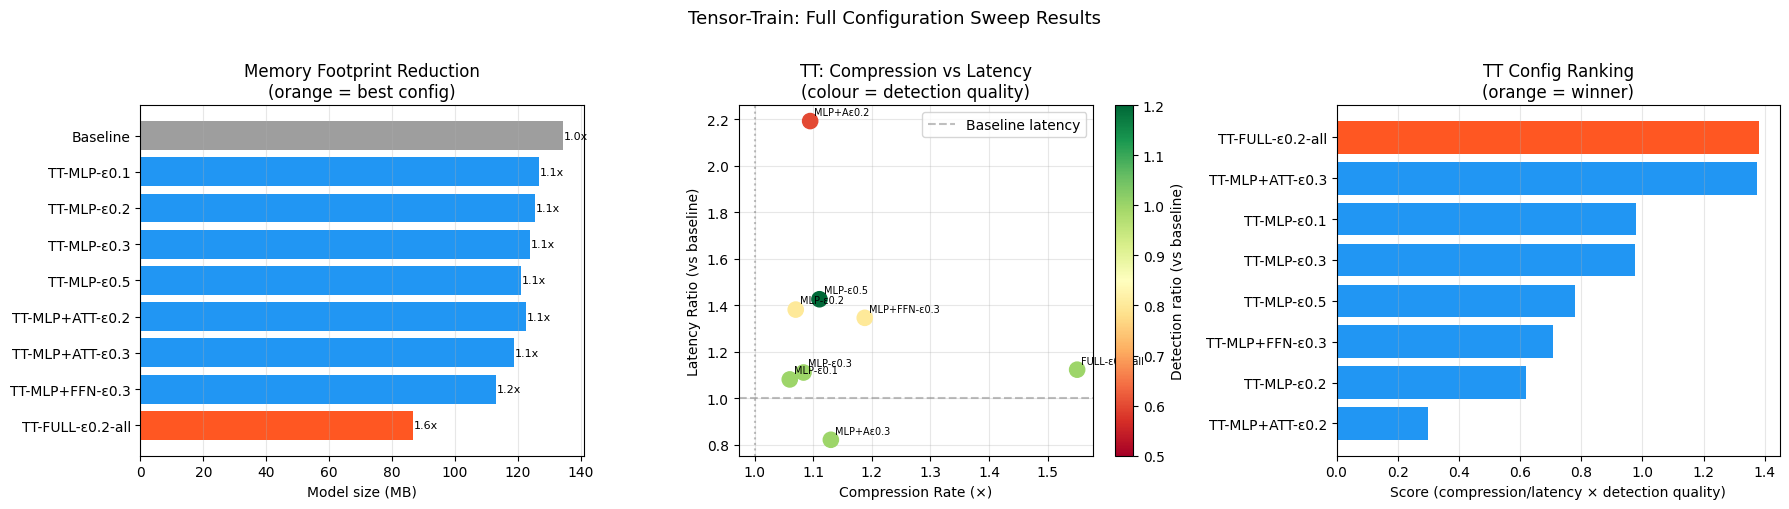

Best TT: TT-FULL-ε0.2-all  |  compression=1.381


In [10]:
# Visualize TT sweep results
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

names   = [r["name"]          for r in tt_results]
cr_vals = [r["compression_rate"] for r in tt_results]
lat_val = [r["latency_ratio"]  for r in tt_results]
det_val = [r["det_ratio"]      for r in tt_results]
scores  = [r["score"]          for r in tt_results]
sizes   = [r["size_bytes"]     for r in tt_results]

x = np.arange(len(names))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Memory footprint ---
bar_colors = ["#2196F3" if n != best_tt_name else "#FF5722" for n in names]
axes[0].barh(["Baseline"] + names, 
             [baseline_bytes / 1e6] + [s / 1e6 for s in sizes],
             color=["#9E9E9E"] + bar_colors)
axes[0].set_xlabel("Model size (MB)")
axes[0].set_title("Memory Footprint Reduction\n(orange = best config)")
axes[0].invert_yaxis()
axes[0].grid(axis="x", alpha=0.3)
for i, (s, cr) in enumerate(zip([baseline_bytes] + sizes, [1.0] + cr_vals)):
    axes[0].text(s / 1e6 + 0.2, i, f"{cr:.1f}x", va="center", fontsize=8)

# --- Plot 2: Compression vs latency ---
sc = axes[1].scatter(cr_vals, lat_val, c=det_val, cmap="RdYlGn", s=120,
                     vmin=0.5, vmax=1.2, zorder=3)
axes[1].axhline(1.0, color="gray", linestyle="--", alpha=0.5, label="Baseline latency")
axes[1].axvline(1.0, color="gray", linestyle=":",  alpha=0.5)
for r in tt_results:
    axes[1].annotate(r["name"].replace("TT-", ""), 
                     (r["compression_rate"], r["latency_ratio"]),
                     fontsize=7, ha="left", va="bottom",
                     xytext=(3, 3), textcoords="offset points")
plt.colorbar(sc, ax=axes[1], label="Detection ratio (vs baseline)")
axes[1].set_xlabel("Compression Rate (×)", fontsize=10)
axes[1].set_ylabel("Latency Ratio (vs baseline)", fontsize=10)
axes[1].set_title("TT: Compression vs Latency\n(colour = detection quality)")
axes[1].legend()
axes[1].grid(alpha=0.3)

# --- Plot 3: Score ranking ---
sorted_by_score = sorted(zip(names, scores), key=lambda x: x[1])
snames, sscores = zip(*sorted_by_score)
scolors = ["#FF5722" if n == best_tt_name else "#2196F3" for n in snames]
axes[2].barh(snames, sscores, color=scolors)
axes[2].set_xlabel("Score (compression/latency × detection quality)")
axes[2].set_title("TT Config Ranking\n(orange = winner)")
axes[2].grid(axis="x", alpha=0.3)

plt.suptitle("Tensor-Train: Full Configuration Sweep Results", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"Best TT: {best_tt_name}  |  compression={best_tt_score:.3f}")

---
## § 7 — Automated Best-CP-Model Search

CP decomposition is applied via `cp_factorize()` using **TensorLy ALS** with multi-start initialization (HOSVD + SVD warm start).  
We sweep CP ranks `[4, 8, 12, 16, 24]` on layers `[8, 9, 10, 11]` of `RFDETRSegNano`.

Same scoring as TT:  $\text{score} = \frac{CR}{\text{lat\_ratio}} \times \min(1, \text{det\_ratio})$

In [11]:
# Automated CP configuration sweep
CP_CONFIGS = [
    # (name,         cp_rank, layer_ids,    mlp,   attn,  ffn)
    ("CP-rank4",      4,  [8, 9, 10, 11], True,  False, False),
    ("CP-rank8",      8,  [8, 9, 10, 11], True,  False, False),
    ("CP-rank12",    12,  [8, 9, 10, 11], True,  False, False),
    ("CP-rank16",    16,  [8, 9, 10, 11], True,  False, False),
    ("CP-rank24",    24,  [8, 9, 10, 11], True,  False, False),
    ("CP-rank8-all",  8,  "all",           True,  False, False),
    ("CP-rank12-all",12,  "all",           True,  False, False),
]

cp_sweep_results = []
best_cp_score = -float("inf")
best_cp_model = None
best_cp_name  = None

print(f"{'Config':<18} {'Size':>9} {'CR':>6} {'Latency':>9} {'Lat.Ratio':>10} {'Dets':>5} {'Score':>8}")
print("-" * 73)

for name, cp_rank, layer_ids, do_mlp, do_attn, do_ffn in CP_CONFIGS:
    try:
        model = RFDETRSegNano()
        model = model.cp_factorize(
            cp_rank=cp_rank,
            layer_ids=layer_ids,
            factorize_backbone_mlp=do_mlp,
            factorize_backbone_attention=do_attn,
            factorize_decoder_ffn=do_ffn,
            init=("svd", "hosvd"),
            als_random_starts=1,
            n_iter_max=80,
            verbose=False,
        )
        size_info = full_model_size_bytes(model, reference_bytes=baseline_bytes, include_cp_state=True)
        bench     = benchmark_predict_strict(model, image, warmup_runs=2, timed_runs=6, label=name)
        dets      = model.predict(image, threshold=0.35)
        n_dets    = len(dets)

        cr  = size_info["compression_rate"] or 1.0
        lat_ratio = bench["mean_s"] / baseline_bench["mean_s"]
        det_ratio = n_dets / max(1, baseline_det_count)
        score = cr / lat_ratio * min(1.0, det_ratio)

        result = {
            "name": name, "cp_rank": cp_rank, "compression_rate": cr,
            "size_bytes": size_info["total_bytes"], "latency_mean_s": bench["mean_s"],
            "latency_ratio": lat_ratio, "det_count": n_dets, "det_ratio": det_ratio,
            "score": score, "model": model,
        }
        cp_sweep_results.append(result)

        print(f"{name:<18} {human_bytes(size_info['total_bytes']):>9} {cr:>6.2f}x "
              f"{bench['mean_s']:>7.4f}s {lat_ratio:>10.2f}x {n_dets:>5} {score:>8.4f}")

        if score > best_cp_score:
            best_cp_score = score
            best_cp_model = model
            best_cp_name  = name

    except Exception as exc:
        print(f"{name:<18} FAILED: {exc}")

print()
print(f"Best CP config : {best_cp_name}  (score={best_cp_score:.4f})")

Config                  Size     CR   Latency  Lat.Ratio  Dets    Score
-------------------------------------------------------------------------
[2026-03-17 16:58:10] [INFO] rf-detr - File rf-detr-seg-nano.pt already exists with correct MD5 hash.


[2026-03-17 16:58:10] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-17 16:58:10] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-17 16:58:11] [INFO] rf-detr - Loading pretrain weights


[2026-03-17 16:58:29] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


CP-rank4           110.21 MB   1.16x  1.1027s       0.71x     0   0.0000
[2026-03-17 16:58:40] [INFO] rf-detr - File rf-detr-seg-nano.pt already exists with correct MD5 hash.


...

CP-rank12          110.44 MB   1.16x  1.5253s       0.98x     0   0.0000
[2026-03-17 16:59:50] [INFO] rf-detr - File rf-detr-seg-nano.pt already exists with correct MD5 hash.


[2026-03-17 16:59:50] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-17 16:59:50] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-17 16:59:50] [INFO] rf-detr - Loading pretrain weights


[2026-03-17 17:00:24] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


CP-rank16          110.56 MB   1.16x  2.0688s       1.33x     0   0.0000
[2026-03-17 17:00:42] [INFO] rf-detr - File rf-detr-seg-nano.pt already exists with correct MD5 hash.
CP-rank24          FAILED: [Errno 2] No such file or directory: 'c:\\Users\\pdenarie\\OneDrive - Deloitte (O365D)\\Desktop\\Python own\\Soccer_Broadcast_LVM\\src\\rfdetr_pierre\\models\\backbone\\dinov2_configs\\dinov2_small.json'
[2026-03-17 17:00:43] [INFO] rf-detr - File rf-detr-seg-nano.pt already exists with correct MD5 hash.
CP-rank8-all       FAILED: [Errno 2] No such file or directory: 'c:\\Users\\pdenarie\\OneDrive - Deloitte (O365D)\\Desktop\\Python own\\Soccer_Broadcast_LVM\\src\\rfdetr_pierre\\models\\backbone\\dinov2_configs\\dinov2_small.json'
[2026-03-17 17:00:43] [INFO] rf-detr - File rf-detr-seg-nano.pt already exists with correct MD5 hash.
CP-rank12-all      FAILED: [Errno 2] No such file or directory: 'c:\\Users\\pdenarie\\OneDrive - Deloitte (O365D)\\Desktop\\Python own\\Soccer_Broadcast_LVM\\s

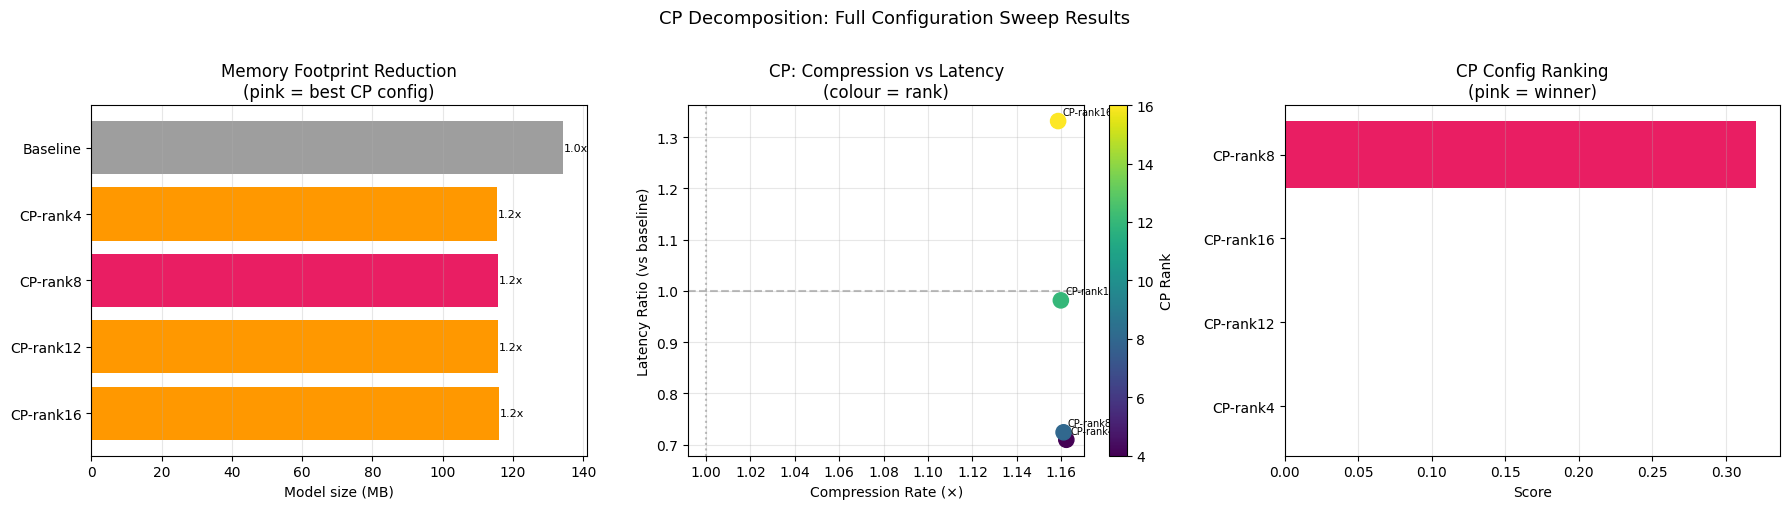

In [12]:
# Visualize CP sweep results
names_cp   = [r["name"]             for r in cp_sweep_results]
cr_cp_vals = [r["compression_rate"] for r in cp_sweep_results]
lat_cp_val = [r["latency_ratio"]    for r in cp_sweep_results]
det_cp_val = [r["det_ratio"]        for r in cp_sweep_results]
scores_cp  = [r["score"]            for r in cp_sweep_results]
sizes_cp   = [r["size_bytes"]       for r in cp_sweep_results]
ranks_cp   = [r["cp_rank"]          for r in cp_sweep_results]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Memory footprint ---
bar_colors_cp = ["#FF9800" if n != best_cp_name else "#E91E63" for n in names_cp]
axes[0].barh(["Baseline"] + names_cp,
             [baseline_bytes / 1e6] + [s / 1e6 for s in sizes_cp],
             color=["#9E9E9E"] + bar_colors_cp)
axes[0].set_xlabel("Model size (MB)")
axes[0].set_title("Memory Footprint Reduction\n(pink = best CP config)")
axes[0].invert_yaxis()
axes[0].grid(axis="x", alpha=0.3)
for i, (s, cr) in enumerate(zip([baseline_bytes] + sizes_cp, [1.0] + cr_cp_vals)):
    axes[0].text(s / 1e6 + 0.2, i, f"{cr:.1f}x", va="center", fontsize=8)

# --- Plot 2: Compression vs latency (rank-colored) ---
sc2 = axes[1].scatter(cr_cp_vals, lat_cp_val, c=ranks_cp, cmap="viridis", s=120, zorder=3)
axes[1].axhline(1.0, color="gray", linestyle="--", alpha=0.5)
axes[1].axvline(1.0, color="gray", linestyle=":",  alpha=0.5)
for r in cp_sweep_results:
    axes[1].annotate(r["name"],
                     (r["compression_rate"], r["latency_ratio"]),
                     fontsize=7, ha="left", va="bottom",
                     xytext=(3, 3), textcoords="offset points")
plt.colorbar(sc2, ax=axes[1], label="CP Rank")
axes[1].set_xlabel("Compression Rate (×)")
axes[1].set_ylabel("Latency Ratio (vs baseline)")
axes[1].set_title("CP: Compression vs Latency\n(colour = rank)")
axes[1].grid(alpha=0.3)

# --- Plot 3: Score ranking ---
sorted_cp = sorted(zip(names_cp, scores_cp), key=lambda x: x[1])
snames_cp, sscores_cp = zip(*sorted_cp)
sc_colors = ["#E91E63" if n == best_cp_name else "#FF9800" for n in snames_cp]
axes[2].barh(snames_cp, sscores_cp, color=sc_colors)
axes[2].set_xlabel("Score")
axes[2].set_title("CP Config Ranking\n(pink = winner)")
axes[2].grid(axis="x", alpha=0.3)

plt.suptitle("CP Decomposition: Full Configuration Sweep Results", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## § 8 — Best Model Selection, Memory Footprint & Performance Trade-off

We now compare the **baseline**, the **best TT model**, and the **best CP model** side-by-side,  
and produce the final publication-quality plots:

1. **Bar chart** — absolute model size in MB for all candidates  
2. **Scatter plot** — compression ratio vs latency ratio, revealing the Pareto front  
3. **Detection quality** — annotated inference on `dog.jpg` with both best models

In [13]:
# Select overall best decomposed model (higher score wins)
if best_tt_score >= best_cp_score:
    best_overall_model  = best_tt_model
    best_overall_name   = f"TT — {best_tt_name}"
    best_overall_method = "TT"
    best_overall_score  = best_tt_score
else:
    best_overall_model  = best_cp_model
    best_overall_name   = f"CP — {best_cp_name}"
    best_overall_method = "CP"
    best_overall_score  = best_cp_score

print(f"Best TT : {best_tt_name} | score={best_tt_score:.4f}")
print(f"Best CP : {best_cp_name} | score={best_cp_score:.4f}")
print(f"Overall winner: {best_overall_name}  (score={best_overall_score:.4f})")

# Build comparison table
baseline_best_tt = next((r for r in tt_results if r["name"] == best_tt_name), None)
baseline_best_cp = next((r for r in cp_sweep_results if r["name"] == best_cp_name), None)

print()
print(f"{'Model':<25} {'Size':>10} {'CR':>7} {'Latency':>9} {'Lat×':>7} {'Dets':>5}")
print("-" * 70)
print(f"{'Baseline':<25} {human_bytes(baseline_bytes):>10} {'1.00x':>7} "
      f"{baseline_bench['mean_s']:>7.4f}s {'1.00x':>7} {baseline_det_count:>5}")
if baseline_best_tt:
    print(f"{best_tt_name:<25} {human_bytes(baseline_best_tt['size_bytes']):>10} "
          f"{baseline_best_tt['compression_rate']:>6.2f}x "
          f"{baseline_best_tt['latency_mean_s']:>7.4f}s "
          f"{baseline_best_tt['latency_ratio']:>6.2f}x {baseline_best_tt['det_count']:>5}")
if baseline_best_cp:
    print(f"{best_cp_name:<25} {human_bytes(baseline_best_cp['size_bytes']):>10} "
          f"{baseline_best_cp['compression_rate']:>6.2f}x "
          f"{baseline_best_cp['latency_mean_s']:>7.4f}s "
          f"{baseline_best_cp['latency_ratio']:>6.2f}x {baseline_best_cp['det_count']:>5}")

Best TT : TT-FULL-ε0.2-all | score=1.3807
Best CP : CP-rank8 | score=0.3207
Overall winner: TT — TT-FULL-ε0.2-all  (score=1.3807)

Model                           Size      CR   Latency    Lat×  Dets
----------------------------------------------------------------------
Baseline                   128.09 MB   1.00x  1.5541s   1.00x     5
TT-FULL-ε0.2-all            82.62 MB   1.55x  1.7451s   1.12x     5
CP-rank8                   110.32 MB   1.16x  1.1254s   0.72x     1


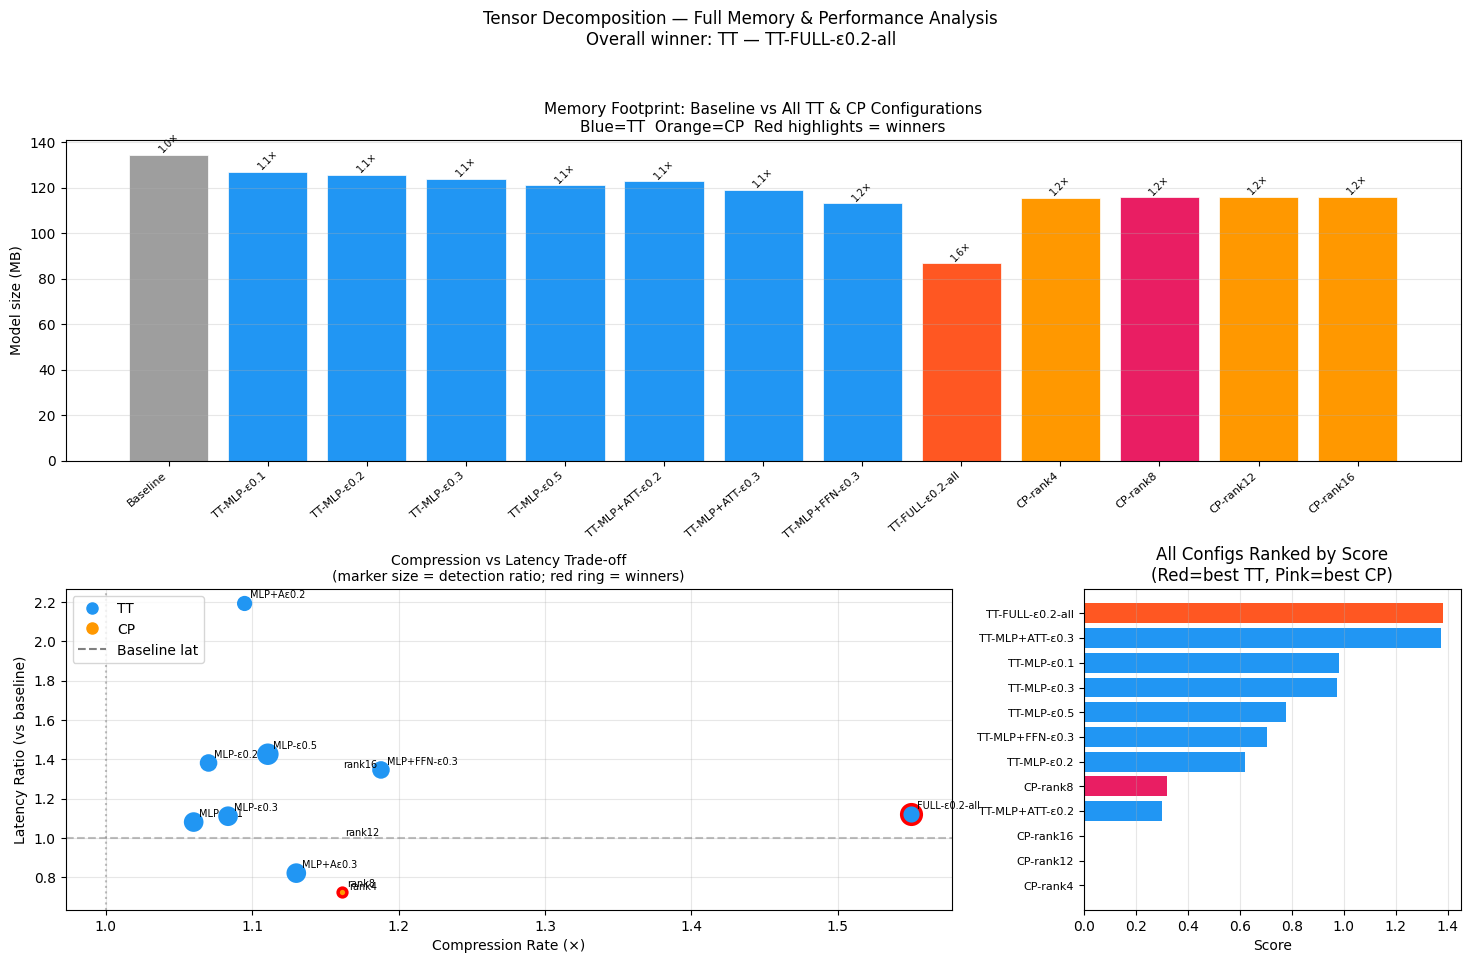

Plot saved to notebooks/tensor_decomp_analysis.png


In [14]:
# Publication-quality comparison plots
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Aggregate all results for unified scatter
all_points = (
    [{"name": r["name"], "cr": r["compression_rate"], "lat": r["latency_ratio"],
      "det": r["det_ratio"], "size": r["size_bytes"], "method": "TT"}
     for r in tt_results]
    +
    [{"name": r["name"], "cr": r["compression_rate"], "lat": r["latency_ratio"],
      "det": r["det_ratio"], "size": r["size_bytes"], "method": "CP"}
     for r in cp_sweep_results]
)

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ─── Plot A: Memory footprint bar chart ─────────────────────────────────────
ax_mem = fig.add_subplot(gs[0, :])
all_names_bar = ["Baseline"] + [r["name"] for r in tt_results] + [r["name"] for r in cp_sweep_results]
all_sizes_mb  = [baseline_bytes / 1e6] + [r["size_bytes"] / 1e6 for r in tt_results] + \
                [r["size_bytes"] / 1e6 for r in cp_sweep_results]
all_cr_bar    = [1.0] + [r["compression_rate"] for r in tt_results] + [r["compression_rate"] for r in cp_sweep_results]

palette = (["#9E9E9E"] +
           ["#FF5722" if n == best_tt_name else "#2196F3" for n in [r["name"] for r in tt_results]] +
           ["#E91E63" if n == best_cp_name else "#FF9800" for n in [r["name"] for r in cp_sweep_results]])

bars = ax_mem.bar(range(len(all_names_bar)), all_sizes_mb, color=palette, edgecolor="white", linewidth=0.5)
ax_mem.set_xticks(range(len(all_names_bar)))
ax_mem.set_xticklabels(all_names_bar, rotation=40, ha="right", fontsize=8)
ax_mem.set_ylabel("Model size (MB)", fontsize=10)
ax_mem.set_title("Memory Footprint: Baseline vs All TT & CP Configurations\n"
                 "Blue=TT  Orange=CP  Red highlights = winners", fontsize=11)
for i, (mb, cr) in enumerate(zip(all_sizes_mb, all_cr_bar)):
    ax_mem.text(i, mb + 0.3, f"{cr:.1f}×", ha="center", va="bottom", fontsize=7, rotation=45)
ax_mem.grid(axis="y", alpha=0.3)

# ─── Plot B: Compression vs Latency scatter ──────────────────────────────────
ax_sc = fig.add_subplot(gs[1, :2])
for pt in all_points:
    color = "#2196F3" if pt["method"] == "TT" else "#FF9800"
    edge  = "red" if (pt["method"]=="TT" and pt["name"]==best_tt_name) or \
                     (pt["method"]=="CP" and pt["name"]==best_cp_name) else "none"
    ax_sc.scatter(pt["cr"], pt["lat"], c=color, s=pt["det"]*200,
                  edgecolors=edge, linewidths=2.5, zorder=3)
    ax_sc.annotate(pt["name"].replace("TT-", "").replace("CP-", ""),
                   (pt["cr"], pt["lat"]), fontsize=7, xytext=(4, 4),
                   textcoords="offset points")
ax_sc.axhline(1.0, color="gray", linestyle="--", alpha=0.5, label="Baseline latency")
ax_sc.axvline(1.0, color="gray", linestyle=":",  alpha=0.5, label="No compression")
import matplotlib.lines as mlines
ax_sc.legend(handles=[
    mlines.Line2D([], [], color="#2196F3", marker="o", markersize=8, label="TT", linestyle="None"),
    mlines.Line2D([], [], color="#FF9800", marker="o", markersize=8, label="CP", linestyle="None"),
    mlines.Line2D([], [], color="gray", linestyle="--", label="Baseline lat"),
], loc="upper left")
ax_sc.set_xlabel("Compression Rate (×)", fontsize=10)
ax_sc.set_ylabel("Latency Ratio (vs baseline)", fontsize=10)
ax_sc.set_title("Compression vs Latency Trade-off\n(marker size = detection ratio; red ring = winners)", fontsize=10)
ax_sc.grid(alpha=0.3)

# ─── Plot C: Score bars ───────────────────────────────────────────────────────
ax_rank = fig.add_subplot(gs[1, 2])
all_scores_bar = [(r["name"], r["score"], "TT") for r in tt_results] + \
                 [(r["name"], r["score"], "CP") for r in cp_sweep_results]
all_scores_bar.sort(key=lambda x: x[1])
sn, ss, sm = zip(*all_scores_bar)
sc_colors2 = []
for n, _, m in all_scores_bar:
    if   n == best_tt_name: sc_colors2.append("#FF5722")
    elif n == best_cp_name: sc_colors2.append("#E91E63")
    elif m == "TT":         sc_colors2.append("#2196F3")
    else:                   sc_colors2.append("#FF9800")
ax_rank.barh(sn, ss, color=sc_colors2)
ax_rank.set_xlabel("Score")
ax_rank.set_title("All Configs Ranked by Score\n(Red=best TT, Pink=best CP)")
ax_rank.grid(axis="x", alpha=0.3)
ax_rank.tick_params(axis='y', labelsize=8)

plt.suptitle(f"Tensor Decomposition — Full Memory & Performance Analysis\n"
             f"Overall winner: {best_overall_name}", fontsize=12, y=1.01)
plt.savefig(PROJECT_ROOT / "notebooks" / "tensor_decomp_analysis.png", dpi=120, bbox_inches="tight")
plt.show()
print("Plot saved to notebooks/tensor_decomp_analysis.png")

In [15]:
# Side-by-side inference: Baseline vs Best TT vs Best CP on dog.jpg
import supervision as sv
from PIL import Image

image_path = DATA_DIR / "raw" / "dog.jpg"
image = Image.open(image_path)

def annotate(model, img, threshold=0.36):
    dets   = model.predict(img, threshold=threshold)
    labels = [COCO_CLASSES[c] for c in dets.class_id]
    ann    = sv.BoxAnnotator().annotate(img.copy(), dets)
    ann    = sv.LabelAnnotator().annotate(ann, dets, labels)
    if hasattr(dets, "mask") and dets.mask is not None:
        ann = sv.MaskAnnotator().annotate(ann, dets)
    return ann, dets

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
titles_models = [
    ("Baseline (no compression)", baseline_model),
    (f"Best TT: {best_tt_name}", best_tt_model),
    (f"Best CP: {best_cp_name}", best_cp_model),
]

for ax, (title, model) in zip(axes, titles_models):
    ann_img, dets = annotate(model, image)
    ax.imshow(ann_img)
    ax.set_title(f"{title}\n{len(dets)} detections", fontsize=9)
    ax.axis("off")

plt.suptitle("Inference Comparison on dog.jpg — Baseline vs Best TT vs Best CP", fontsize=12)
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\pdenarie\\OneDrive - Deloitte (O365D)\\Desktop\\Python own\\Soccer_Broadcast_LVM\\data\\raw\\dog.jpg'

---
## § 9 — TT + Core Quantization: Stacking Two Compression Layers

TT decomposition reduces the **number of stored values** by replacing dense weight matrices with chains of small cores. After factorization, those cores are still stored in **float32** (4 bytes/value).  
We can apply a second compression layer: **casting the TT cores to a lower-precision dtype**, reducing bytes-per-core-element by 2×.

### How it works

The `TTDinov2WithRegistersMLP` forward pass:
1. Contracts the TT cores → reconstructs the stacked `[2, 1536, 384]` tensor
2. Slices out `W̃₁` and `W̃₂ᵀ`, then calls `F.linear` in the inference dtype (float32)

So quantizing the **cores to float16/bfloat16** does not change the computation graph — reconstruction always returns float32 tensors for the linear layers. The saving is purely in **memory storage** for the cores.

### Dtypes compared

| Core dtype | Bytes/value | Dynamic range | Notes |
|-----------|-------------|---------------|-------|
| `float32` | 4 | ±3.4×10³⁸ | Default |
| `float16` | 2 | ±65 504 | Fast on GPU; slow on CPU |
| `bfloat16` | 2 | ±3.4×10³⁸ | Good on CPU (AVX-512 BF16) |
| `float8_e4m3fn` | 1 | ±448 | 4-exp / 3-mantissa bits; finite-only; for weights & activations; GPU only (H100 / Ada) |
| `float8_e5m2` | 1 | ±57 344 | 5-exp / 2-mantissa bits; wider range; for gradients; GPU only (H100 / Ada) |

> **Note on CPU (our environment):** PyTorch CPU float16 matmuls lack hardware acceleration on most machines, so latency may *increase* despite the memory saving. bfloat16 is typically better supported on modern Intel/AMD CPUs. The memory win is real regardless of latency.


In [ ]:

# § 9 — TT + Core Quantization sweep
import torch
import types
from rfdetr_pierre import RFDETRSegNano
from rfdetr_pierre.models.backbone.dinov2_with_windowed_attn import TTDinov2WithRegistersMLP

# ── Helpers ───────────────────────────────────────────────────────────────────

def quantize_tt_cores(model, dtype):
    """Cast TT cores to `dtype` for storage; patch _dense_weights to upcast
    cores to float32 during contraction (CPU fp16/bf16 matmul not supported
    by tntorch).  Memory saving is real; compute path is unchanged.
    """
    n = 0
    for m in model.model.model.modules():
        if not isinstance(m, TTDinov2WithRegistersMLP):
            continue
        # Store cores in lower precision
        m.tt_tensor.cores = [c.to(dtype) for c in m.tt_tensor.cores]

        # Capture `m` in the closure so each patch refers to its own module
        def _make_patch(mod):
            def _patched_dense_weights(self_m, compute_dtype, device):
                # Temporarily upcast cores to float32 for the TT contraction
                # (tntorch uses torch.einsum/matmul which require float32 on CPU)
                low_prec_cores = self_m.tt_tensor.cores
                self_m.tt_tensor.cores = [c.float() for c in low_prec_cores]
                stacked = self_m.tt_tensor.torch()          # float32 result
                self_m.tt_tensor.cores = low_prec_cores     # restore stored dtype
                stacked = stacked.to(device=device, dtype=compute_dtype)
                return stacked[0], stacked[1].T
            mod._dense_weights = types.MethodType(_patched_dense_weights, mod)

        _make_patch(m)
        n += 1
    return model, n


def tt_core_bytes(model):
    """Sum raw bytes of all TT cores (counting each tensor once)."""
    seen, total = set(), 0
    for m in model.model.model.modules():
        if isinstance(m, TTDinov2WithRegistersMLP):
            for c in m.tt_tensor.cores:
                if id(c) not in seen:
                    seen.add(id(c))
                    total += c.numel() * c.element_size()
    return total


# ── Recover best TT kwargs ────────────────────────────────────────────────────

best_tt_cfg = next(cfg for cfg in TT_CONFIGS if cfg[0] == best_tt_name)
_name, _layer_ids, _do_mlp, _do_attn, _do_ffn, _eps_mlp, _eps_attn, _eps_ffn = best_tt_cfg

def _build_best_tt():
    m = RFDETRSegNano()
    kw = dict(
        layer_ids=_layer_ids,
        cache_policy="none",
        verbose=False,
        factorize_backbone_mlp=_do_mlp,
        factorize_backbone_attention=_do_attn,
        factorize_decoder_ffn=_do_ffn,
    )
    if _eps_mlp  is not None: kw["eps_backbone_mlp"]       = _eps_mlp
    if _eps_attn is not None: kw["eps_backbone_attention"]  = _eps_attn
    if _eps_ffn  is not None: kw["eps_decoder_ffn"]         = _eps_ffn
    return m.tt_factorize(**kw)


# ── Sweep: fp32 (no quant) | fp16 | bf16 ─────────────────────────────────────

QUANT_CONFIGS = [
    ("TT fp32",   None),
    ("TT + FP16", torch.float16),
    ("TT + BF16", torch.bfloat16),
    ("TT + FP8_e4m3fn", torch.float8_e4m3fn),
    ("TT + FP8_e5m2", torch.float8_e5m2),
]

quant_results = []

print(f"Base TT config : {best_tt_name}")
print(f"{'Variant':<14} {'Core dtype':<12} {'Core bytes':>11} {'Total MB':>10} {'CR':>7} "
      f"{'Lat (s)':>9} {'Lat×':>7} {'Dets':>5}  Score")
print("-" * 92)

for variant_name, qdtype in QUANT_CONFIGS:
    try:
        model_q = _build_best_tt()
        if qdtype is not None:
            model_q, _ = quantize_tt_cores(model_q, qdtype)

        core_bytes_q = tt_core_bytes(model_q)
        # Read stored dtype from any patched or unpatched module
        sample_core = next(
            c
            for mod in model_q.model.model.modules()
            if isinstance(mod, TTDinov2WithRegistersMLP)
            for c in mod.tt_tensor.cores
        )
        core_dtype = sample_core.dtype

        size_info = full_model_size_bytes(model_q, reference_bytes=baseline_bytes)
        bench_q   = benchmark_predict_strict(model_q, image, warmup_runs=2, timed_runs=6, label=variant_name)
        dets_q    = model_q.predict(image, threshold=0.35)
        n_dets_q  = len(dets_q)
        lat_ratio = bench_q["mean_s"] / baseline_bench["mean_s"]
        det_ratio = n_dets_q / max(1, baseline_det_count)
        cr        = size_info["compression_rate"] or 1.0
        score     = cr / lat_ratio * min(1.0, det_ratio)

        quant_results.append({
            "name":        variant_name,
            "dtype":       str(core_dtype),
            "core_bytes":  core_bytes_q,
            "total_bytes": size_info["total_bytes"],
            "cr":          cr,
            "lat_mean_s":  bench_q["mean_s"],
            "lat_ratio":   lat_ratio,
            "det_count":   n_dets_q,
            "det_ratio":   det_ratio,
            "score":       score,
            "model":       model_q,
        })

        print(f"{variant_name:<14} {str(core_dtype):<12} {human_bytes(core_bytes_q):>11} "
              f"{size_info['total_bytes']/1e6:>8.1f} MB {cr:>6.2f}x "
              f"{bench_q['mean_s']:>7.4f}s {lat_ratio:>6.2f}x {n_dets_q:>5}  {score:.4f}")

    except Exception as exc:
        import traceback
        print(f"{variant_name:<14} FAILED: {exc}")
        traceback.print_exc()

print()
if len(quant_results) >= 2:
    base_core = quant_results[0]["core_bytes"]
    for r in quant_results[1:]:
        saving = (1 - r["core_bytes"] / base_core) * 100
        print(f"{r['name']}: core bytes ↓ {saving:.0f}%  "
              f"({human_bytes(r['core_bytes'])} vs {human_bytes(base_core)} fp32)")


Base TT config : TT-FULL-ε0.2-all
Variant        Core dtype    Core bytes   Total MB      CR   Lat (s)    Lat×  Dets  Score
--------------------------------------------------------------------------------------------
[2026-03-17 15:47:32] [INFO] rf-detr - File rf-detr-seg-nano.pt already exists with correct MD5 hash.


[2026-03-17 15:47:32] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-17 15:47:32] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-17 15:47:33] [INFO] rf-detr - Loading pretrain weights


[2026-03-17 15:47:46] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


TT fp32        torch.float32    28.57 MB     86.6 MB   1.55x  2.9419s   3.21x     5  0.4835
[2026-03-17 15:48:12] [INFO] rf-detr - File rf-detr-seg-nano.pt already exists with correct MD5 hash.


...

TT + FP8_e4m3fn torch.float8_e4m3fn     7.14 MB     64.2 MB   2.09x  2.0794s   2.27x     1  0.1847
[2026-03-17 15:50:36] [INFO] rf-detr - File rf-detr-seg-nano.pt already exists with correct MD5 hash.


[2026-03-17 15:50:36] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-17 15:50:36] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-17 15:50:37] [INFO] rf-detr - Loading pretrain weights


[2026-03-17 15:50:55] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


TT + FP8_e5m2  torch.float8_e5m2     7.14 MB     64.2 MB   2.09x  1.7653s   1.92x     5  1.0878

TT + FP16: core bytes ↓ 50%  (14.28 MB vs 28.57 MB fp32)
TT + BF16: core bytes ↓ 50%  (14.28 MB vs 28.57 MB fp32)
TT + FP8_e4m3fn: core bytes ↓ 75%  (7.14 MB vs 28.57 MB fp32)
TT + FP8_e5m2: core bytes ↓ 75%  (7.14 MB vs 28.57 MB fp32)


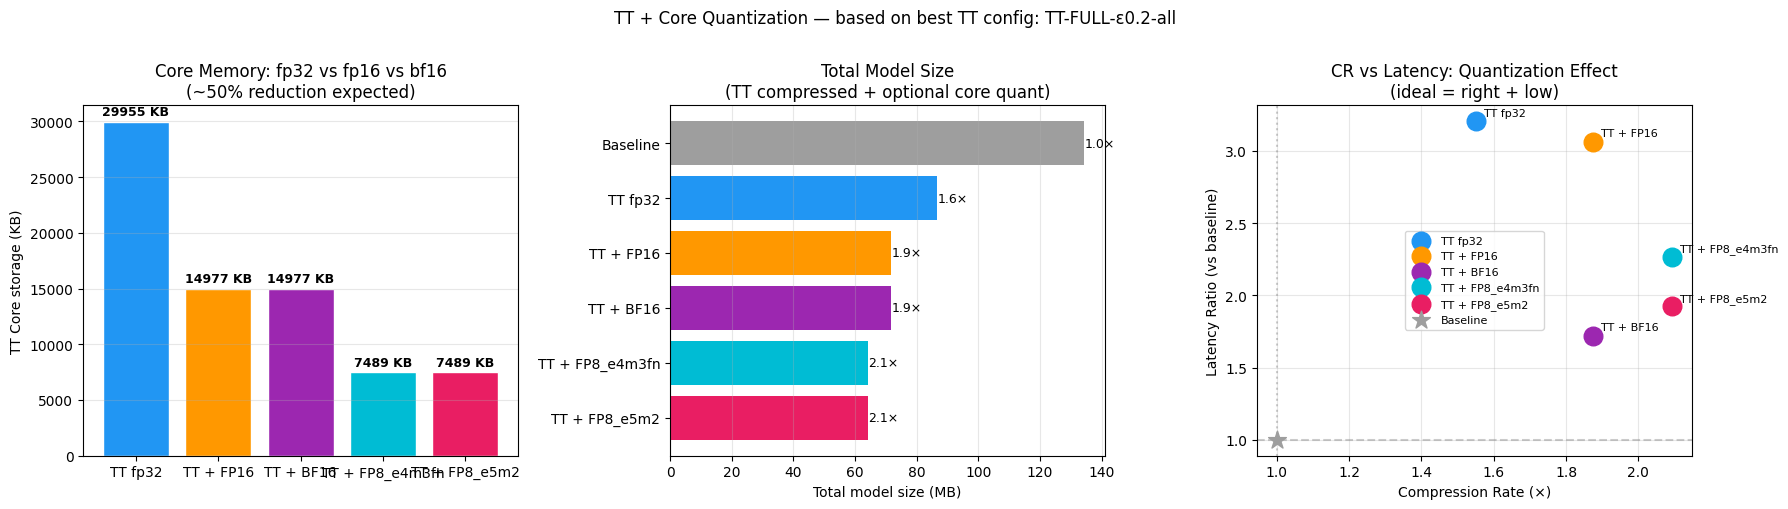

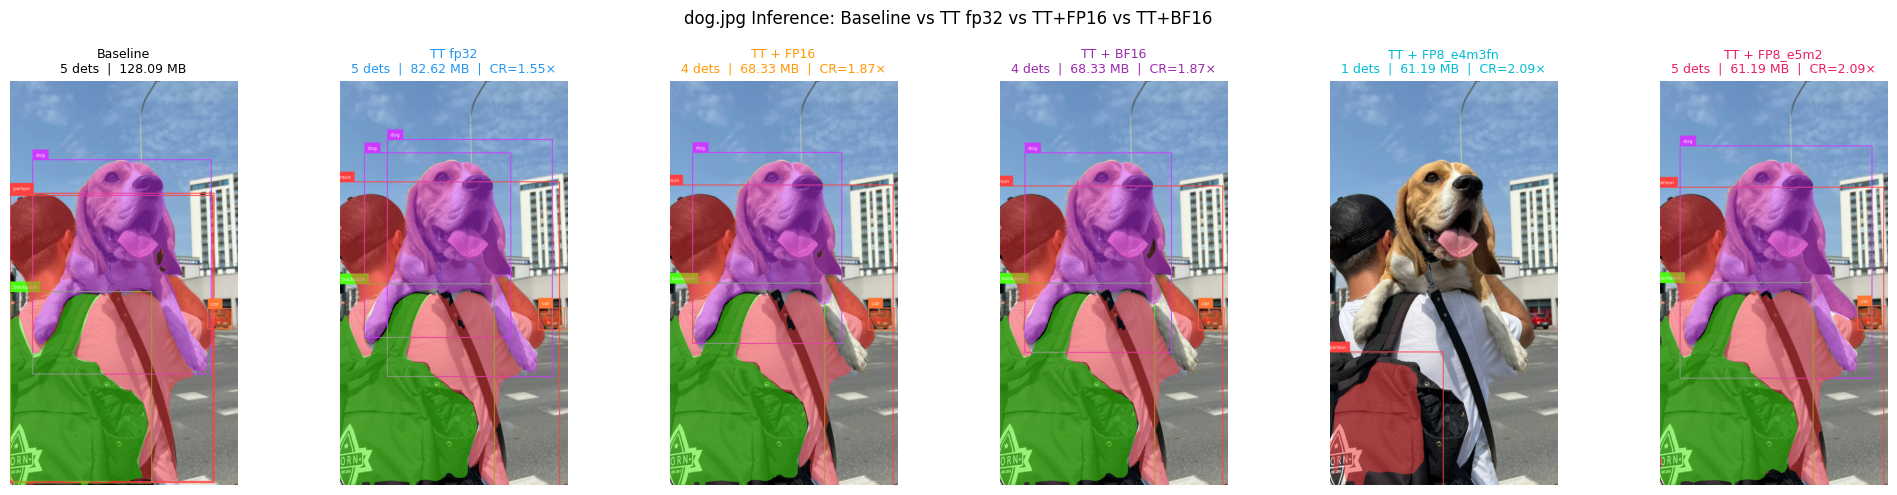


Best quantized model : TT + FP8_e5m2
  Score        : 1.0878
  Compression  : 2.09×  vs baseline
  Memory       : 61.19 MB
  Latency×     : 1.92
  Detections   : 5 (baseline=5)

→ This model will be used for video segmentation in § 10.


In [ ]:
# § 9 — Quantization visualisation + best quantized model selection
import matplotlib.pyplot as plt
import numpy as np

names_q  = [r["name"]          for r in quant_results]
total_mb = [r["total_bytes"]/1e6 for r in quant_results]
core_kb  = [r["core_bytes"]/1e3  for r in quant_results]
crs_q    = [r["cr"]            for r in quant_results]

colors_q = ["#2196F3", "#FF9800", "#9C27B0", "#00BCD4", "#E91E63"]  # fp32 blue, fp16 orange, bf16 purple, fp8_e4m3fn cyan, fp8_e5m2 magenta

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Core memory (KB) ─────────────────────────────────────────────────
bars1 = axes[0].bar(names_q, core_kb, color=colors_q, edgecolor="white")
for bar, kb in zip(bars1, core_kb):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + core_kb[0]*0.01,
                 f"{kb:.0f} KB", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[0].set_ylabel("TT Core storage (KB)")
axes[0].set_title("Core Memory: fp32 vs fp16 vs bf16\n(~50% reduction expected)")
axes[0].grid(axis="y", alpha=0.3)

# ── Plot 2: Total model size vs baseline ──────────────────────────────────────
all_labels   = ["Baseline"] + names_q
all_sizes_mb = [baseline_bytes / 1e6] + total_mb
all_colors   = ["#9E9E9E"] + colors_q
bars2 = axes[1].barh(all_labels, all_sizes_mb, color=all_colors)
axes[1].set_xlabel("Total model size (MB)")
axes[1].set_title("Total Model Size\n(TT compressed + optional core quant)")
axes[1].invert_yaxis()
axes[1].grid(axis="x", alpha=0.3)
for bar, (mb, cr) in zip(bars2, zip(all_sizes_mb, [1.0] + crs_q)):
    axes[1].text(mb + 0.2, bar.get_y() + bar.get_height()/2,
                 f"{cr:.1f}×", va="center", fontsize=9)

# ── Plot 3: CR vs latency scatter ─────────────────────────────────────────────
for i, r in enumerate(quant_results):
    axes[2].scatter(r["cr"], r["lat_ratio"], color=colors_q[i], s=180, zorder=3,
                    label=r["name"])
    axes[2].annotate(r["name"], (r["cr"], r["lat_ratio"]),
                     fontsize=8, xytext=(6, 4), textcoords="offset points")
axes[2].scatter(1.0, 1.0, color="#9E9E9E", s=180, marker="*", zorder=4, label="Baseline")
axes[2].axhline(1.0, color="gray", linestyle="--", alpha=0.4)
axes[2].axvline(1.0, color="gray", linestyle=":",  alpha=0.4)
axes[2].set_xlabel("Compression Rate (×)")
axes[2].set_ylabel("Latency Ratio (vs baseline)")
axes[2].set_title("CR vs Latency: Quantization Effect\n(ideal = right + low)")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.suptitle(f"TT + Core Quantization — based on best TT config: {best_tt_name}", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# ── Side-by-side dog.jpg inference ───────────────────────────────────────────
fig2, axes2 = plt.subplots(1, len(quant_results) + 1, figsize=(20, 5))
ann_base, dets_base = annotate(baseline_model, image)
axes2[0].imshow(ann_base)
axes2[0].set_title(f"Baseline\n{len(dets_base)} dets  |  {human_bytes(baseline_bytes)}", fontsize=9)
axes2[0].axis("off")

for ax2, r, color in zip(axes2[1:], quant_results, colors_q):
    ann_q, _ = annotate(r["model"], image)
    ax2.imshow(ann_q)
    ax2.set_title(
        f"{r['name']}\n{r['det_count']} dets  |  {human_bytes(r['total_bytes'])}  |  CR={r['cr']:.2f}×",
        fontsize=9, color=color,
    )
    ax2.axis("off")
    for spine in ax2.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

plt.suptitle("dog.jpg Inference: Baseline vs TT fp32 vs TT+FP16 vs TT+BF16", fontsize=12)
plt.tight_layout()
plt.show()

# ── Select best quantized model (same score formula as §6/§7) ────────────────
best_quant = max(quant_results, key=lambda r: r["score"])
best_quant_model = best_quant["model"]
best_quant_name  = best_quant["name"]

print(f"\nBest quantized model : {best_quant_name}")
print(f"  Score        : {best_quant['score']:.4f}")
print(f"  Compression  : {best_quant['cr']:.2f}×  vs baseline")
print(f"  Memory       : {human_bytes(best_quant['total_bytes'])}")
print(f"  Latency×     : {best_quant['lat_ratio']:.2f}")
print(f"  Detections   : {best_quant['det_count']} (baseline={baseline_det_count})")
print(f"\n→ This model will be used for video segmentation in § 10.")


---
## § 10 — Video Segmentation with the Best Quantized Model

We now run the **best model from § 9** on `football_play.mp4` — a raw soccer broadcast clip.

The winner is selected by the same scoring formula used throughout this notebook:

$$
\text{score} = \frac{CR}{\text{lat\_ratio}} \times \min\!\left(1, \frac{N_{\text{dets}}}{N_{\text{baseline}}}\right)
$$

This means the video is processed with a model that has been **doubly compressed**: first by TT decomposition (§ 6), then by core dtype quantization (§ 9). The pipeline writes the annotated output to `data/processed/football_play_decomposed.mp4`.


In [ ]:

import cv2
import supervision as sv
from PIL import Image
from tqdm import tqdm
import numpy as np

# Use the best quantized model from § 9
video_model      = best_quant_model
video_model_name = best_quant_name

input_video  = DATA_DIR / "raw"       / "football_play.mp4"
output_video = DATA_DIR / "processed" / "football_play_decomposed.mp4"

if not input_video.exists():
    print(f"[WARN] {input_video} not found. Skipping video segmentation.")
else:
    cap      = cv2.VideoCapture(str(input_video))
    fps      = int(cap.get(cv2.CAP_PROP_FPS)) or 25
    width    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"Input  : {input_video}")
    print(f"Output : {output_video}")
    print(f"Format : {width}×{height} @ {fps} fps  — {n_frames} frames")
    print(f"Model  : {video_model_name}  (doubly compressed: TT + core quant)")
    bq_info = next(r for r in quant_results if r["name"] == video_model_name)
    print(f"Memory : {human_bytes(bq_info['total_bytes'])}  (CR={bq_info['cr']:.2f}× vs baseline)")
    print()

    fourcc          = cv2.VideoWriter_fourcc(*"mp4v")
    out             = cv2.VideoWriter(str(output_video), fourcc, fps, (width, height))
    box_annotator   = sv.BoxAnnotator()
    mask_annotator  = sv.MaskAnnotator(opacity=0.45)
    label_annotator = sv.LabelAnnotator(text_scale=0.5, text_thickness=1)

    frame_idx = 0
    with tqdm(total=n_frames, desc="Segmenting video", unit="frame") as pbar:
        while True:
            ret, frame_bgr = cap.read()
            if not ret:
                break

            pil_frame = Image.fromarray(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))

            try:
                detections = video_model.predict(pil_frame, threshold=0.30)
                labels     = [COCO_CLASSES[c] for c in detections.class_id]
                ann        = box_annotator.annotate(pil_frame.copy(), detections)
                ann        = label_annotator.annotate(ann, detections, labels)
                if hasattr(detections, "mask") and detections.mask is not None:
                    ann = mask_annotator.annotate(ann, detections)
                ann_bgr = cv2.cvtColor(np.array(ann), cv2.COLOR_RGB2BGR)
            except Exception:
                ann_bgr = frame_bgr  # fallback: write original frame on error

            if frame_idx == 0:
                cv2.putText(ann_bgr, f"Model: {video_model_name}", (10, 30),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)

            out.write(ann_bgr)
            frame_idx += 1
            pbar.update(1)

    cap.release()
    out.release()
    print(f"Video written to: {output_video}  ({frame_idx} frames)")

    # Show a sample frame
    cap_check = cv2.VideoCapture(str(output_video))
    cap_check.set(cv2.CAP_PROP_POS_FRAMES, min(30, frame_idx - 1))
    ret2, sample = cap_check.read()
    cap_check.release()
    if ret2:
        plt.figure(figsize=(12, 6))
        plt.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
        plt.title(f"Sample output frame — model: {video_model_name}", fontsize=11)
        plt.axis("off")
        plt.tight_layout()
        plt.show()


Input  : C:\Users\pdenarie\OneDrive - Deloitte (O365D)\Desktop\Python own\Soccer_Broadcast_LVM\data\raw\football_play.mp4
Output : C:\Users\pdenarie\OneDrive - Deloitte (O365D)\Desktop\Python own\Soccer_Broadcast_LVM\data\processed\football_play_decomposed.mp4
Format : 1920×1080 @ 10 fps  — 600 frames
Model  : TT + BF16  (doubly compressed: TT + core quant)
Memory : 68.33 MB  (CR=1.87× vs baseline)



Segmenting video:  24%|██▍       | 147/600 [08:00<24:42,  3.27s/frame]


KeyboardInterrupt: 